Phases: ['BCC_A2', 'FCC_A1', 'LIQUID', 'LAVES_C14', 'LAVES_C15', 'MU_PHASE', 'SIGMA']
Elements: ['VA', 'FE', 'NB', '/-', 'CR']


c:\Users\alans\anaconda3\envs\calphad\Lib\site-packages\pycalphad\io\tdb.py:293: UserWarning: The type definition character `C` in `TYPE_DEFINITION C GES AMEND_PHASE_DESCRIPTION CBCC_A12 MAGNETIC -3 0.280, ` is not used by any phase.
  warnings.warn(f"The type definition character `{typechar}` in `TYPE_DEFINITION {typechar} {line}` is not used by any phase.")
c:\Users\alans\anaconda3\envs\calphad\Lib\site-packages\pycalphad\io\tdb.py:1017: UserWarning: The type definition character `R` was defined in the following phases: ['LIQUID'], but no corresponding TYPE_DEFINITION line was found in the TDB.
  warnings.warn(f"The type definition character `{typechar}` was defined in the following phases: "


Phases: ['LIQUID', 'ALB2', 'ALB12_ALPHA', 'ALB12_BETA', 'AL4C3', 'AL4SIC4', 'AL8SIC7', 'AL2_CEND', 'AL11_CEND3L', 'AL11_CEND3H', 'AL_CEND3L', 'AL_CEND3H', 'AL3_CEND', 'AL_CEND', 'ALCE_AMORPHOUS', 'ALCR2', 'AL4CR', 'AL8CR5_H', 'AL8CR5_L', 'AL9CR4_H', 'AL9CR4_L', 'AL11CR2', 'AL13CR2', 'ALCU_DELTA', 'ALCU_EPSILON', 'ALCU_ETA', 'ALCU_THETA', 'ALCU_PRIME', 'ALCU_ZETA', 'ALCULI_TB', 'ALCULI_R', 'ALCULI_T1', 'ALCULI_T2', 'ALCUZN_T', 'AL13FE4', 'AL2FE', 'AL5FE2', 'AL5FE4', 'ALFESI_ALPHA', 'ALFESI_BETA', 'ALFESI_GAMMA', 'ALFESI_DELTA', 'ALFESI_TAU1', 'ALFESI_TAU3', 'ALLI', 'AL2LI3', 'AL4LI9', 'AL12MG17', 'ALLIMG_TAU', 'ALMG_BETA', 'ALMG_EPS', 'ALMG_GAMMA', 'ALMGMN_T', 'AL11MN4', 'AL12MN', 'AL4MN', 'AL6MN', 'AL8MN5_D810', 'ALMNSI_ALPHA', 'ALMNSI_BETA', 'ALMNSI_DELTA', 'AL12MO', 'AL4MO', 'AL5MO', 'AL63MO37', 'AL8MO3', 'ALMO', 'ALN', 'ALND_AMORPHOUS', 'ALND2', 'ALSNZR', 'ALTI', 'ALM_D019', 'AL2TI', 'AL3M_D022', 'AL3TA2_L', 'AL3TA2_H', 'AL11TI5', 'AL7V', 'AL8V5', 'AL10V', 'AL23V4', 'AL12W', 'AL2W',

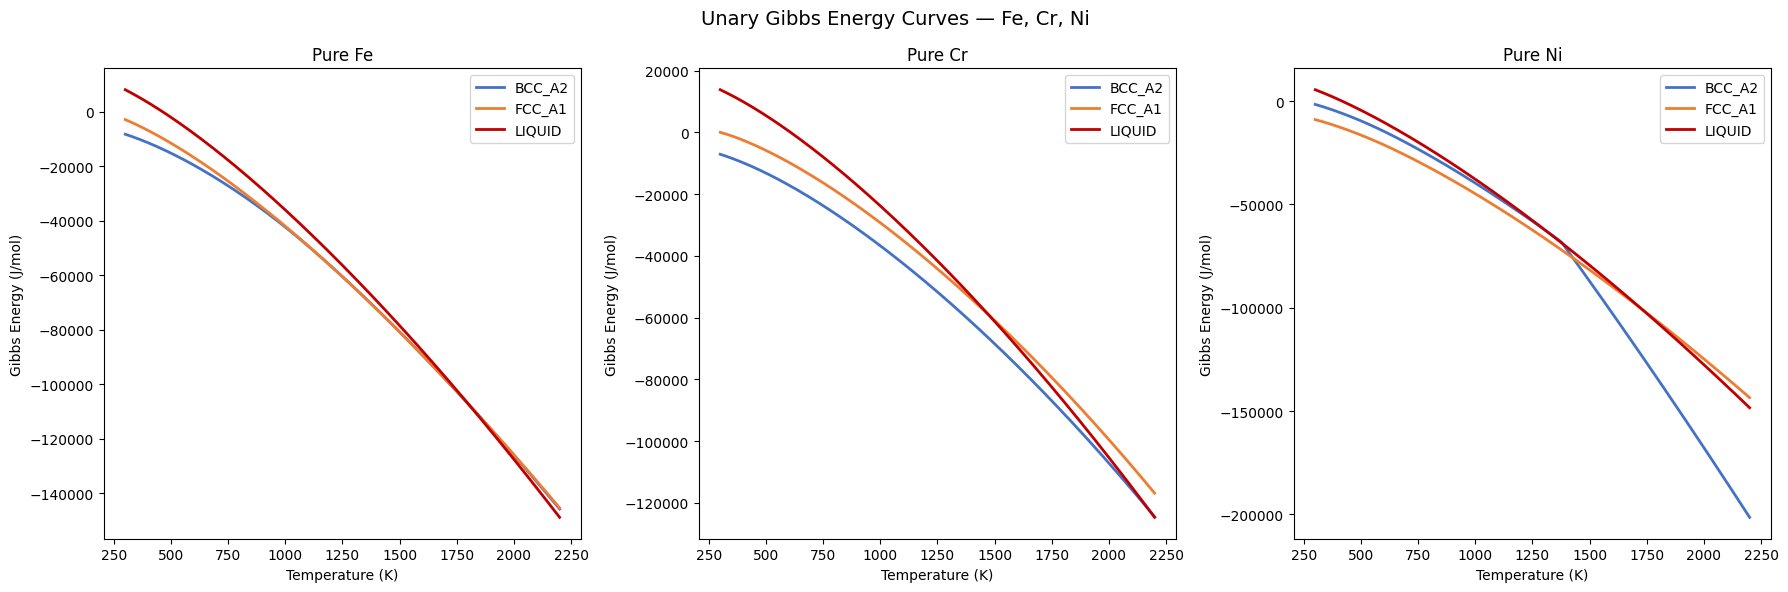

In [24]:
from pycalphad import Database, calculate, equilibrium
import pycalphad.variables as v
import numpy as np
import matplotlib.pyplot as plt

dbf3 = Database(db_folder + r"\CrFeNb_Jacob2016.tdb")
print("Phases:", list(dbf3.phases.keys()))
print("Elements:", list(dbf3.elements))

dbf4 = Database(db_folder + r"\COST507.tdb")
print("Phases:", list(dbf4.phases.keys()))
print("Elements:", list(dbf4.elements))

# Cell 1: Unary Gibbs Energy — Fe, Cr, Ni
T_range = np.linspace(300, 2200, 200)
phases_unary = ['BCC_A2', 'FCC_A1', 'LIQUID']
colors = {'BCC_A2': '#4472C4', 'FCC_A1': '#ED7D31', 'LIQUID': '#C00000'}

# Fe and Cr from CrFeNb_Jacob2016 (dbf3), Ni from alcocrni (dbf2)
elements = [('FE', dbf3), ('CR', dbf3), ('NI', dbf2)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (element, db) in zip(axes, elements):
    for phase in phases_unary:
        try:
            result = calculate(db, [element, 'VA'], phase,
                               T=T_range, P=101325, output='GM')
            gm = result.GM.min(dim='points').values.squeeze()
            ax.plot(T_range, gm, label=phase, color=colors[phase], linewidth=2)
        except:
            pass

    ax.set_xlabel('Temperature (K)')
    ax.set_ylabel('Gibbs Energy (J/mol)')
    ax.set_title(f'Pure {element.capitalize()}')
    ax.legend()

plt.suptitle('Unary Gibbs Energy Curves — Fe, Cr, Ni', fontsize=14)
plt.tight_layout()
plt.show()

# CALPHAD calculates Gibbs free energy (G = H - TS) for each phase vs temperature.
# The phase with the lowest G is stable. As T rises, entropy drives G down to liquids
# drop fastest, crossing below solids at the melting point.

# Ni stays FCC and Cr stays BCC from room temperature to melting.
# Fe is the anomaly: BCC → FCC → BCC → liquid, changing structure twice due to
# magnetic entropy effects — this is what makes steel heat-treatable.
# Adding Cr pulls Fe toward BCC, adding Ni pulls Fe toward FCC.
# This competition drives the binary and ternary phase diagrams.

# NOTE: BCC_A2 line for Ni is a database artefact — alcocrni.tdb was fitted for
# Al-Co-Cr-Ni alloy mixtures, not pure Ni. BCC Ni does not exist in nature.
# Ni remains FCC up to melting at 1728 K. Extrapolated end-members can appear
# physically reasonable but be thermodynamically meaningless outside the fitted range.


Calculating Fe-Cr binary phase diagram...
Done!
<xarray.Dataset> Size: 793kB
Dimensions:    (N: 1, P: 1, T: 60, X_CR: 50, vertex: 3, component: 2,
                internal_dof: 4)
Coordinates:
  * N          (N) float64 8B 1.0
  * P          (P) float64 8B 1.013e+05
  * T          (T) float64 480B 500.0 527.1 554.2 ... 2.073e+03 2.1e+03
  * X_CR       (X_CR) float64 400B 0.02 0.03959 0.05918 ... 0.9408 0.9604 0.98
  * vertex     (vertex) int64 24B 0 1 2
  * component  (component) <U2 16B 'CR' 'FE'
Dimensions without coordinates: internal_dof
Data variables:
    NP         (N, P, T, X_CR, vertex) float64 72kB 0.0008815 0.9991 ... nan nan
    GM         (N, P, T, X_CR) float64 24kB -1.516e+04 -1.512e+04 ... -1.178e+05
    MU         (N, P, T, X_CR, component) float64 48kB -1.319e+04 ... -2.039e+05
    X          (N, P, T, X_CR, vertex, component) float64 144kB 0.9916 ... nan
    Y          (N, P, T, X_CR, vertex, internal_dof) float64 288kB 0.9916 ......
    Phase      (N, P, T, X_CR, ve

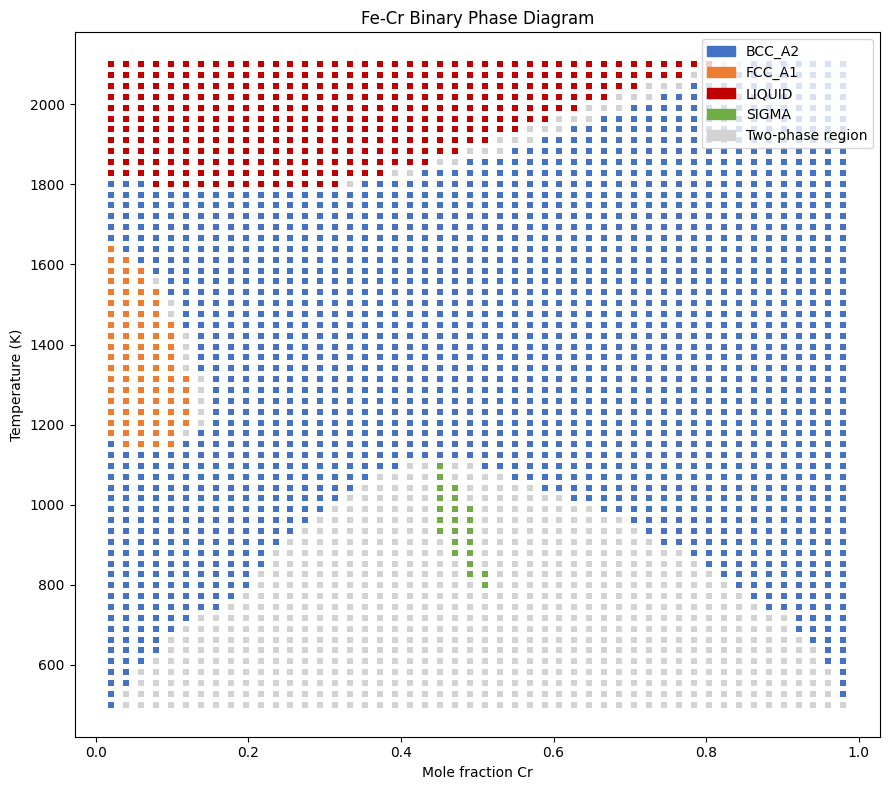

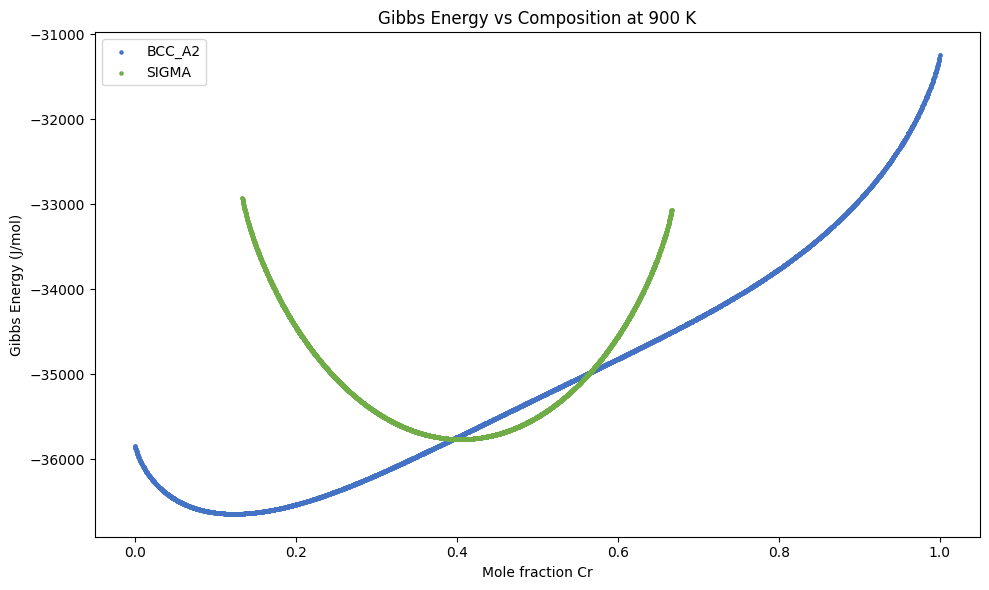

In [ ]:
# Cell 2: Fe-Cr binary phase diagram
phases_fecr = ['BCC_A2', 'FCC_A1', 'LIQUID', 'SIGMA']

T_range_binary = np.linspace(500, 2100, 60)
x_cr_range = np.linspace(0.02, 0.98, 50)

print("Calculating Fe-Cr binary phase diagram...")

result_fecr = equilibrium(dbf3, ['FE', 'CR', 'VA'], phases_fecr,
                          {v.P: 101325,
                           v.T: T_range_binary,
                           v.X('CR'): x_cr_range})

print("Done!")
print(result_fecr)

# equilibrium() finds which phase(s) minimise total Gibbs energy at every T and composition simultaneously

import matplotlib.patches as mpatches

colors = {
    'BCC_A2': '#4472C4',
    'FCC_A1': '#ED7D31',
    'LIQUID':  '#C00000',
    'SIGMA':   '#70AD47',
}

fig, ax = plt.subplots(figsize=(9, 8))

phases_arr = result_fecr.Phase.values[0, 0, :, :, :]  # shape: T, X_CR, vertex
np_arr     = result_fecr.NP.values[0, 0, :, :, :]     # shape: T, X_CR, vertex

#checks the storage slots on your diagram fo where what phase is where
#phases_arr contains the phase names at each T and compositon
#np_arr contains the mole fractions of each phase at each T and compsotion

#enumerate gives you a y value for a x value and a x value for a y value

for i, T in enumerate(T_range_binary):
    for j, x in enumerate(x_cr_range):
        stable = [phases_arr[i, j, k] for k in range(3)
                  if phases_arr[i, j, k] != '' 
                  and not np.isnan(np_arr[i, j, k]) 
                  and np_arr[i, j, k] > 0.01]

        if len(stable) == 1:
            color = colors.get(stable[0], 'grey')
        elif len(stable) >= 2:
            color = 'lightgrey'
        else:
            color = 'white'

        ax.plot(x, T, 's', color=color, markersize=5, markeredgewidth=0)

#line 91: loops through each temperature and composition point, checks which phases are stable
#line 93: i is the row, j is the column, k is the vertex (for range of upto 3 phases)
#line 94: checks if the phase is not empty
#line 95: checks if the mole fraction is not a number (NaN)

#the loop goes through the different compositions and checks the temperature values
#sees if that value gives a number and the number of phases there are in that unit of data

patches = [mpatches.Patch(color=colors[p], label=p) for p in colors]
patches.append(mpatches.Patch(color='lightgrey', label='Two-phase region'))
ax.legend(handles=patches)
ax.set_xlabel('Mole fraction Cr')
ax.set_ylabel('Temperature (K)')
ax.set_title('Fe-Cr Binary Phase Diagram')
plt.tight_layout()
plt.show()

# what this graph shows
#1.  as you increase the concentreation of Cr, at low temperature the two solids are iminscible and do not mix, buta s you increase the temperature the two solids become miscible
#2.  the sigma phase appears at intermediate temperatures and compositions, and the liquid phase appears at high temperatures
#a sigma phase forms at intermediate temperatures and compositions, this is when a unstable alloy forms, and the two solids are not stable, and brittle
#3.  the FCC phase happens at low Cr concentrations and high temperatures, while the BCC phase happens at high Cr concentrations and low temperatures
#4   liquid at high temperatures

#why is there a two phase around the fcc and bcc phases? because the two phases are not stable as they're different crystal structures
#why is there a two phase region around the liquid phase? because they are now liquid and have their own activity and melting points which effect at which points the two metals will melt and mix together

# Cell 3: Gibbs energy vs composition at fixed temperature
# Shows the two energy wells that create the two-phase region

T_fixed = 900  # K — inside the two-phase region

fig, ax = plt.subplots(figsize=(10, 6))

for phase, color in [('BCC_A2', '#4472C4'), ('SIGMA', '#70AD47')]:
    try:
        result = calculate(dbf3, ['FE', 'CR', 'VA'], phase,
                           T=T_fixed, P=101325, output='GM')
        x_cr = result.X.sel(component='CR').values.squeeze()
        gm   = result.GM.values.squeeze()
        ax.scatter(x_cr, gm, label=phase, color=color, s=5)
    except Exception as e:
        print(f"{phase}: {e}")

ax.set_xlabel('Mole fraction Cr')
ax.set_ylabel('Gibbs Energy (J/mol)')
ax.set_title(f'Gibbs Energy vs Composition at {T_fixed} K')
ax.legend()
plt.tight_layout()
plt.show()

# the Gibbs energy vs composition plot shows the two energy wells that create the two-phase region.
#the left side from 0 to 0.4 is the BCC phase and to the right from 0.6 to 1 is the sigma phase
#inbetween 0.4 - 0.6 is the two phase region where we see on the gibbs free energy vs composition graoh there is a minimum point on the green curve showing that there is a 2 phase stable region
#This directly corresponds with what we see on our temperature, composition phase diagram where there is a 2 phase region and a sigma phase between 0.4 - 0.6
#hence our range of Cr composition must be between 0.15 - 0.4


Calculating Fe-Ni binary phase diagram...
Done!


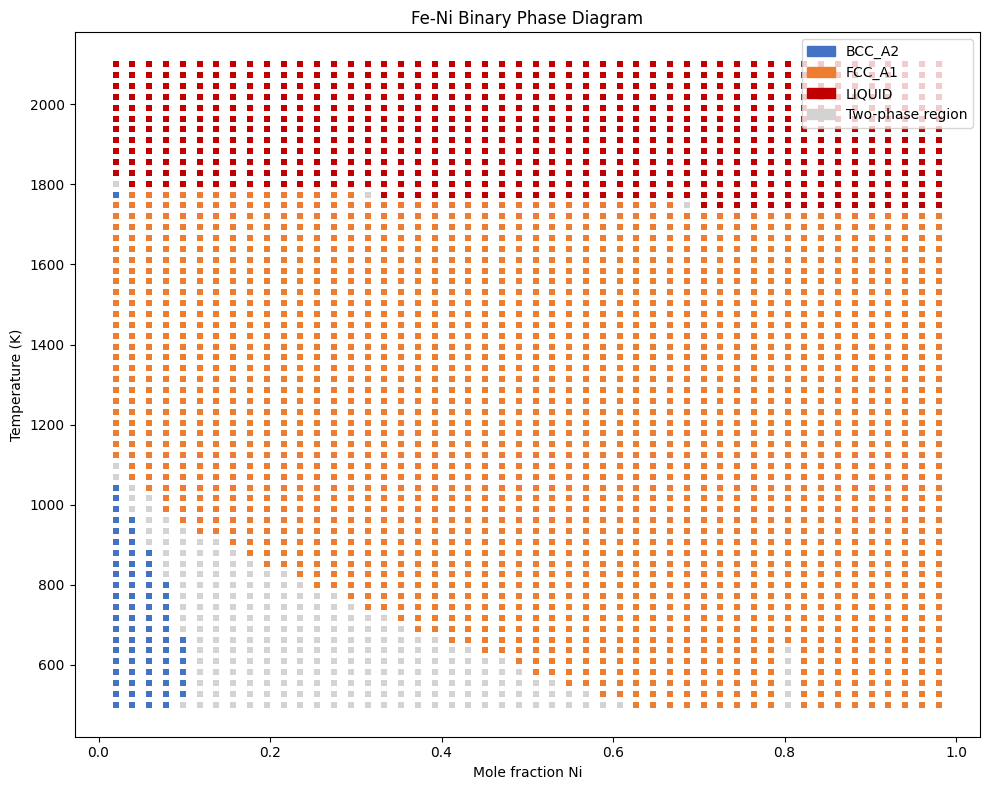

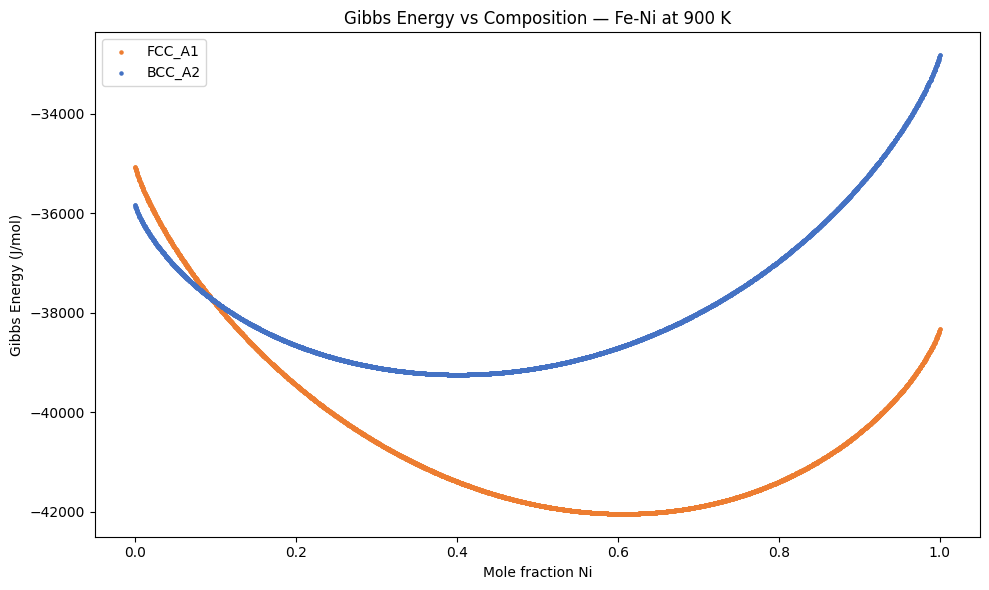

In [ ]:
# Cell 4: Fe-Ni binary phase diagram calculation
phases_feni = ['BCC_A2', 'FCC_A1', 'LIQUID']
# No sigma phase expected — Ni stabilises FCC, doesn't form sigma with Fe

T_range_feni = np.linspace(500, 2100, 60)
x_ni_range = np.linspace(0.02, 0.98, 50)

print("Calculating Fe-Ni binary phase diagram...")

result_feni = equilibrium(dbf4, ['FE', 'NI', 'VA'], phases_feni,
                          {v.P: 101325,
                           v.T: T_range_feni,
                           v.X('NI'): x_ni_range})

print("Done!")

fig, ax = plt.subplots(figsize=(10, 8))

phases_arr_feni = result_feni.Phase.values[0, 0, :, :, :]
np_arr_feni     = result_feni.NP.values[0, 0, :, :, :]

colors_feni = {
    'BCC_A2': '#4472C4',
    'FCC_A1': '#ED7D31',
    'LIQUID':  '#C00000',
}

for i, T in enumerate(T_range_feni):
    for j, x in enumerate(x_ni_range):
        stable = [phases_arr_feni[i, j, k] for k in range(3)
                  if phases_arr_feni[i, j, k] != ''
                  and not np.isnan(np_arr_feni[i, j, k])
                  and np_arr_feni[i, j, k] > 0.01]

        if len(stable) == 1:
            color = colors_feni.get(stable[0], 'grey')
        elif len(stable) >= 2:
            color = 'lightgrey'
        else:
            color = 'white'

        ax.plot(x, T, 's', color=color, markersize=5, markeredgewidth=0)

patches = [mpatches.Patch(color=colors_feni[p], label=p) for p in colors_feni]
patches.append(mpatches.Patch(color='lightgrey', label='Two-phase region'))
ax.legend(handles=patches)
ax.set_xlabel('Mole fraction Ni')
ax.set_ylabel('Temperature (K)')
ax.set_title('Fe-Ni Binary Phase Diagram')
plt.tight_layout()
plt.show()

# 2 stage region happens because Ni is FCC and hence influences the FCC to happen a lot sooner than Cr for the Fe-Cr system, which has a BCC ground state.
#This creates a large two-phase region where both BCC and FCC are stable, and the transition from BCC to FCC happens in two stages instead of one.
#BCC occurs at very low Ni concentrations because of the influence the fcc structure has on the system, and the fact that Ni is FCC and hence stabilises the FCC phase.
#No sigma phase 
# Fe-Ni stabilises as single phase FCC across the full composition range
# Fe and Ni are chemically compatible (similar atomic size, electronegativity, valence per Hume-Rothery)
# so the FCC Gibbs energy curve has a single minimum with no double well, meaning no
# driving force for sigma phase or phase separation. Contrast with Fe-Cr where BCC and
# SIGMA create two minima at intermediate compositions, producing the two-phase region.

# Cell 5: Gibbs energy vs composition for Fe-Ni at 900K
# Expect single smooth FCC curve with one minimum — no double well, no two-phase region

T_fixed_feni = 900  # K

fig, ax = plt.subplots(figsize=(10, 6))

for phase, color in [('FCC_A1', '#ED7D31'), ('BCC_A2', '#4472C4')]:
    try:
        result = calculate(dbf4, ['FE', 'NI', 'VA'], phase,
                           T=T_fixed_feni, P=101325, output='GM')
        x_ni = result.X.sel(component='NI').values.squeeze()
        gm   = result.GM.values.squeeze()
        ax.scatter(x_ni, gm, label=phase, color=color, s=5)
    except Exception as e:
        print(f"{phase}: {e}")

ax.set_xlabel('Mole fraction Ni')
ax.set_ylabel('Gibbs Energy (J/mol)')
ax.set_title(f'Gibbs Energy vs Composition — Fe-Ni at {T_fixed_feni} K')
ax.legend()
plt.tight_layout()

# Fe-Ni G vs X at 900K shows FCC as a single smooth minimum below BCC at all compositions.
# Unlike Fe-Cr where BCC and SIGMA cross to create two minima and a common tangent,
# Fe-Ni has no crossing point — FCC always wins, confirming no sigma phase and no
# two-phase region in the solid. Ni stabilises FCC across the full composition range.

# The BCC curve sits entirely above FCC at all compositions at 900K — meaning even
# pure Fe at this temperature prefers FCC (gamma-Fe), consistent with the unary diagram.
#this entirely avoids the sigma phase which is what we want

#distinct FCC region from Ni composition of 0.1